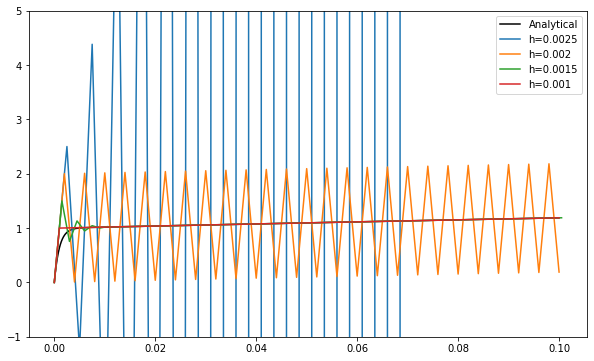

In [7]:
import numpy as np
import matplotlib.pyplot as plt
def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)
def analytical_sol(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)
def forward_euler(h, t_start=0, t_end=0.1, y0=0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    y_values[0] = y0    
    for i in range(1, len(t_values)):
        y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])
        if abs(y_values[i]) > 1e5: 
            y_values[i:] = np.nan
            break            
    return t_values, y_values
plt.figure(figsize=(10, 6))
h_list = [0.0025, 0.002, 0.0015, 0.001] 
t_exact = np.linspace(0, 0.1, 1000)
plt.plot(t_exact, analytical_sol(t_exact), 'k-', label='Analytical')
for h in h_list:
    t_num, y_num = forward_euler(h, t_end=0.1)
    plt.plot(t_num, y_num, label=f'h={h}')
plt.ylim(-1, 5)
plt.legend()
plt.show()